# Day 4 — Deep Learning Engineering

## Note 4.4 — The Bake-Off: Gradient Boosting against a Neural Network

### How to read this note

This note answers one question:

> **Given a real dataset, how do I decide which of two models to ship — and defend the decision?**

This is Day 4's practical, and the course blueprint is unusually firm about it: the conclusion is not allowed to be "neural networks win". It has to be a decision you could defend to a colleague who disagrees with you.

So the note is less about the two models than about how a fair comparison is run. Rules written down before the first result. Identical rows for both sides. Tuning budgets declared in advance. Every difference checked against the noise you measured in Note 4.2. And a cost column and a robustness column beside the accuracy column, because a model that is 0.008 better and thirteen times slower is not obviously the better choice.

Everything is built in this notebook. Nothing is imported from another one.

### Learning goal and outcome

**Goal:** run a controlled comparison between two models and write a decision you can defend.

```text
write the rules          ← before any result exists
      ↓
run both models on the SAME rows, ten times
      ↓
difference bigger than the noise?     → accuracy column
      ↓
how much does each one cost to train, run and ship?   → cost column
      ↓
what happens when the world shifts?   → robustness column
      ↓
a written decision
```

**Outcome:** by the end of this note you should be able to:

- write the rules of a comparison before you see any numbers;
- explain why comparing two models on the same rows is stronger than comparing their averages;
- tell a real difference from noise, and say when a small difference is still real;
- recognise tuning that only looks like an improvement;
- measure the costs that do not appear in a score;
- put a confidence interval on a result when you have only one test set;
- write a decision memo and an experiment record for each side.

### Objectives

By the end of this note you should be able to:

- explain what "pre-registering" a comparison means and why it matters;
- describe in one sentence what gradient boosting does;
- explain why a **paired** comparison has less noise than an unpaired one;
- compute and read a paired difference across ten splits;
- measure training time, prediction time and artifact size fairly;
- run a **bootstrap** and say what its interval covers and what it does not;
- read a per-slice table and say what it changes about what you do next.

### Datasets used

**UCI Bank Marketing**, exactly as in Notes 4.1, 4.2 and 4.3: `duration` dropped, a stratified 80/10/10 split for the main comparison, and the chronological split from 4.1 for the robustness check.

Reusing the Day 3 dataset is the whole point. The neural network's settings are frozen at what Day 3 arrived at, and its number is already known, so nothing on that side can be quietly re-tuned to win. Only the gradient-boosting side is new.

### Table of contents

1. [The rules, written before any result](#s1)
2. [Why the same rows matter](#s2)
3. [Side one: the neural network](#s3)
4. [Side two: gradient boosting](#s4)
5. [Ten splits, paired](#s5)
6. [Does the tuning survive the noise?](#s6)
7. [The cost column](#s7)
8. [The robustness column](#s8)
9. [Where the two models disagree](#s9)
10. [The decision memo](#s10)
11. [Your turn](#s11)

### Runtime budget

| Section | Approximate time |
|---|---|
| Downloading the data (first run only) | 20–60 s |
| Sections 3–4, including the twelve-setting search | ~25 s |
| Section 5 — ten splits, three models each | ~110 s |
| Sections 7–9 | ~25 s |

About **three minutes** after the download. Everything runs on CPU, which also keeps the timing comparison fair: scikit-learn's gradient boosting has no GPU version, so putting the network on a GPU would compare two different machines.

### Environment setup

In [1]:
# pip install torch==2.14.0 scikit-learn==1.8.0 numpy==2.4.4 pandas==3.0.2 \
#             matplotlib==3.10.8 scipy==1.17.0

import copy
import io
import itertools
import json
import os
import time
import urllib.request
import zipfile

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 25)

print("torch       ", torch.__version__)
import sklearn
print("scikit-learn", sklearn.__version__)

torch        2.14.0+cpu


scikit-learn 1.8.0


In [2]:
if torch.cuda.is_available():
    DEVICE, ACCELERATOR = torch.device("cuda"), torch.cuda.get_device_name(0)
elif torch.backends.mps.is_available():
    DEVICE, ACCELERATOR = torch.device("mps"), "Apple Silicon GPU (MPS)"
else:
    DEVICE, ACCELERATOR = torch.device("cpu"), "none"

print(f"accelerator found : {ACCELERATOR}")
print("both models run on CPU, so the timing comparison is like for like")

accelerator found : none
both models run on CPU, so the timing comparison is like for like


<a id="s1"></a>
## 1. The rules, written before any result

The way model comparisons usually go wrong is not dishonesty. It is drift.

You run both models. One looks worse. You adjust it a little, rerun, it improves. You adjust it again. By the end, one model has had an afternoon of your attention and the other has had five minutes, and what you have measured is **effort**, not models.

The defence is to write the rules first, run them, and report what happened — including the parts you did not like. This is sometimes called **pre-registering** a comparison, and it is borrowed from clinical trials, where the same problem is much more serious.

Here are this comparison's rules.

**The question.** For this dataset, at this size, with this deployment story, which model would we ship?

**Data and splits.** Bank Marketing, `duration` dropped. Stratified 80/10/10, with split seeds 0 to 9. Both models see **identical rows** on every split.

**The main measure.** Test ROC-AUC, at the settings and epoch chosen on the validation rows. Second measure: test PR-AUC, always printed next to the share of positives that sets its floor (Note 4.1 Section 7).

**Tuning budget.** The neural network is **frozen** at the Day 3 settings: 50 inputs → 64 → 32 → 1, AdamW at 0.001, batch 256, 30 epochs, best epoch chosen on validation. Gradient boosting gets scikit-learn's defaults, plus **one search over twelve settings**, scored on the validation rows of split seed 42 only, then applied unchanged to all ten splits.

**The decision rule.** A difference counts as real only if it is bigger than the split-to-split noise from Note 4.2 **and** consistent in direction across splits. Accuracy alone does not decide: training time, prediction time, artifact size and behaviour under the Note 4.1 shift all count.

**What would change our mind.** If the two land within the noise on accuracy, the decision goes to the cost and robustness columns. If the ranking flips under the chronological split, then neither model is fit to deploy until the shift is dealt with.

One imbalance is worth stating in advance, because no table will show it. The network's settings are the product of two days of work across Notes 2.3 to 3.4. Gradient boosting gets twelve settings and no architecture search at all. So if the network wins narrowly, that imbalance is a reason for caution. If it loses, the imbalance makes the loss more convincing.

**Questions to sit with**

1. Why does writing the tuning budget down beforehand matter more than making it large?
2. The rules insist both models see identical rows. What does that buy? Section 2 answers it.

<a id="s2"></a>
## 2. Why the same rows matter

Note 4.2 measured two kinds of wobble in this model's score. Changing the seed moved test AUC by a standard deviation of 0.0010. Changing the split moved it by 0.0130.

So a gap of 0.01 between two models measured on **different** splits means nothing. Measured on the **same** splits, it might mean a great deal. Here is why, on numbers we control, before we touch the real ones.

Imagine each split has its own difficulty, which both models feel equally — some test sets simply contain harder customers. On top of that each model has a small wobble of its own. Model B is genuinely better by 0.008.

In [3]:
generator = np.random.default_rng(0)

split_difficulty = generator.normal(0, 0.013, 10)          # shared by both models
model_a = 0.800 + split_difficulty + generator.normal(0, 0.002, 10)
model_b = 0.808 + split_difficulty + generator.normal(0, 0.002, 10)   # truly 0.008 better

print(f"model A: average {model_a.mean():.4f}, standard deviation {model_a.std(ddof=1):.4f}")
print(f"model B: average {model_b.mean():.4f}, standard deviation {model_b.std(ddof=1):.4f}")
print()
print("Each model's own spread is bigger than the gap between them.")
print("Reported separately, the comparison looks inconclusive.")

model A: average 0.8002, standard deviation 0.0093
model B: average 0.8091, standard deviation 0.0094

Each model's own spread is bigger than the gap between them.
Reported separately, the comparison looks inconclusive.


In [4]:
difference = model_b - model_a

print("split-by-split difference (B minus A):")
print(np.round(difference, 4))
print()
print(f"average difference  : {difference.mean():+.4f}")
print(f"standard deviation  : {difference.std(ddof=1):.4f}")
print(f"B ahead on          : {int((difference > 0).sum())} of 10 splits")

split-by-split difference (B minus A):
[0.009  0.0107 0.0113 0.0091 0.0123 0.0097 0.0076 0.0068 0.0063 0.0064]

average difference  : +0.0089
standard deviation  : 0.0021
B ahead on          : 10 of 10 splits


The same ten pairs of numbers, read two ways. Summarised separately, the models are indistinguishable. Subtracted split by split, the advantage is obvious and consistent.

The reason is that **the shared difficulty cancels**. When both models are scored on the same test rows, part of each score is "how hard were these rows", and that part is identical for both. Subtract, and it disappears, leaving only the part that depends on the model.

This is called a **paired comparison**, and it is the single most useful trick in this note. Keep it in mind for Section 5, which has exactly this shape with real models.

<a id="s3"></a>
## 3. Side one: the neural network

Now the real thing. First the data and the training function — the same ones from Notes 4.1 and 4.2, brought along so this notebook stands alone.

In [5]:
BANK_URL = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
BANK_CSV = "data/bank-full.csv"

def load_bank_marketing(path=BANK_CSV):
    """Download if needed, drop `duration`, return inputs X and label y."""
    if not os.path.exists(path):
        raw_bytes = urllib.request.urlopen(BANK_URL, timeout=120).read()
        outer = zipfile.ZipFile(io.BytesIO(raw_bytes))
        inner = zipfile.ZipFile(io.BytesIO(outer.read("bank.zip")))
        os.makedirs(os.path.dirname(path), exist_ok=True)
        with open(path, "wb") as f:
            f.write(inner.read("bank-full.csv"))
    df = pd.read_csv(path, sep=";")
    y = (df["y"] == "yes").astype(np.float32).to_numpy()
    return df.drop(columns=["y", "duration"]), y

X, y = load_bank_marketing()
print("rows:", len(X), "| input columns:", X.shape[1], "| share who said yes:", round(float(y.mean()), 4))

rows: 45211 | input columns: 15 | share who said yes: 0.117


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def make_split(y, policy="stratified", fractions=(0.8, 0.1, 0.1), seed=42):
    """Note 4.1's split function: returns row numbers for train, val and test."""
    f_train, f_val, f_test = fractions
    rows = np.arange(len(y))
    test_share_of_rest = f_test / (f_val + f_test)
    if policy == "chronological":
        a, b = int(round(f_train * len(y))), int(round((f_train + f_val) * len(y)))
        return {"train": rows[:a], "val": rows[a:b], "test": rows[b:]}
    train, rest = train_test_split(rows, train_size=f_train, random_state=seed, stratify=y)
    val, test = train_test_split(rest, test_size=test_share_of_rest, random_state=seed, stratify=y[rest])
    return {"train": train, "val": val, "test": test}

def build_preprocessor(X):
    """Scale the numbers, one-hot the categories (Note 4.1 Section 5)."""
    numeric = X.select_dtypes(include="number").columns.tolist()
    categorical = [c for c in X.columns if c not in numeric]
    return ColumnTransformer([
        ("scale", StandardScaler(), numeric),
        ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical),
    ])

split_42 = make_split(y, "stratified", seed=42)
print({part: len(rows) for part, rows in split_42.items()})

{'train': 36168, 'val': 4521, 'test': 4522}


The training function is Note 4.2's, trimmed to what this comparison needs. It seeds everything, splits, fits the preprocessing on training rows only, trains for 30 epochs, keeps the best epoch by validation AUC, and then scores the test rows once.

In [7]:
def seed_everything(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

NN_SETTINGS = dict(name="nn", split="stratified", split_seed=42, seed=42,
                   hidden=(64, 32), lr=1e-3, weight_decay=0.0, batch_size=256, epochs=30)

def run_neural_network(settings, quiet=False, results_dir="results"):
    """Train the Day 3 network once and report its test score."""
    settings = {**NN_SETTINGS, **settings}
    seed_everything(settings["seed"])

    split = make_split(y, settings["split"], seed=settings["split_seed"])
    pre = build_preprocessor(X).fit(X.iloc[split["train"]])
    arrays = {part: pre.transform(X.iloc[rows]).astype(np.float32) for part, rows in split.items()}
    labels = {part: y[rows] for part, rows in split.items()}

    X_train = torch.tensor(arrays["train"])
    y_train = torch.tensor(labels["train"]).unsqueeze(1)
    X_val, X_test = torch.tensor(arrays["val"]), torch.tensor(arrays["test"])

    torch.manual_seed(settings["seed"])
    layers, previous = [], X_train.shape[1]
    for width in settings["hidden"]:
        layers += [nn.Linear(previous, width), nn.ReLU()]
        previous = width
    layers.append(nn.Linear(previous, 1))
    model = nn.Sequential(*layers)

    # weight_decay=0.0 is part of the frozen Day 3 settings. AdamW would otherwise use 0.01.
    optimizer = torch.optim.AdamW(model.parameters(), lr=settings["lr"],
                                  weight_decay=settings["weight_decay"])
    loss_function = nn.BCEWithLogitsLoss()
    generator = torch.Generator().manual_seed(settings["seed"])
    loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_train, y_train),
                                         batch_size=settings["batch_size"], shuffle=True,
                                         generator=generator)

    def probabilities_for(inputs):
        model.eval()
        with torch.no_grad():
            return torch.sigmoid(model(inputs).float()).numpy().ravel()

    best = {"auc": -1.0, "epoch": 0, "weights": None}
    started = time.perf_counter()
    for epoch in range(1, settings["epochs"] + 1):
        model.train()
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            loss_function(model(batch_x), batch_y).backward()
            optimizer.step()
        val_auc = roc_auc_score(labels["val"], probabilities_for(X_val))
        if val_auc > best["auc"]:
            best = {"auc": val_auc, "epoch": epoch, "weights": copy.deepcopy(model.state_dict())}
    seconds = time.perf_counter() - started

    model.load_state_dict(best["weights"])              # back to the best epoch
    test_probabilities = probabilities_for(X_test)
    result = {
        "name": settings["name"], "model": "neural network", "settings": settings,
        "best_epoch": best["epoch"], "val_auc": best["auc"],
        "test": {"auc": float(roc_auc_score(labels["test"], test_probabilities)),
                 "pr_auc": float(average_precision_score(labels["test"], test_probabilities)),
                 "accuracy": float(accuracy_score(labels["test"], test_probabilities > 0.5)),
                 "share_who_said_yes": float(labels["test"].mean()),
                 "average_prediction": float(test_probabilities.mean())},
        "seconds": seconds,
    }
    os.makedirs(results_dir, exist_ok=True)
    with open(os.path.join(results_dir, f"{settings['name']}.json"), "w") as f:
        json.dump(result, f, indent=2, default=str)
    if not quiet:
        print(f"[{settings['name']}] {seconds:.1f}s | best epoch {best['epoch']} | "
              f"val AUC {best['auc']:.4f} | test AUC {result['test']['auc']:.4f}")
    result["artifacts"] = {"model": model, "preprocessor": pre, "split": split,
                           "test_probabilities": test_probabilities}
    return result

nn_reference = run_neural_network({"name": "bakeoff_nn_42"})
print()
print(f"parameters          : {sum(p.numel() for p in nn_reference['artifacts']['model'].parameters()):,}")
print(f"inputs after encoding: {nn_reference['artifacts']['preprocessor'].transform(X.iloc[:1]).shape[1]}")
print(f"test PR-AUC         : {nn_reference['test']['pr_auc']:.4f} "
      f"(share who said yes in the test rows: {nn_reference['test']['share_who_said_yes']:.4f})")

[bakeoff_nn_42] 7.2s | best epoch 18 | val AUC 0.7871 | test AUC 0.8016

parameters          : 5,377
inputs after encoding: 50
test PR-AUC         : 0.4715 (share who said yes in the test rows: 0.1170)


Best epoch 18, validation AUC 0.7871, which is Note 4.2's number reproduced exactly. The test AUC beside it is the number this comparison will use.

<a id="s4"></a>
## 4. Side two: gradient boosting

**Gradient boosting** builds many small decision trees, one after another, where each new tree is trained to fix the errors the trees so far are still making. Predictions are the sum of all the trees. It is not a neural network, it has no layers or epochs, and on tabular data it is the model most practitioners reach for first.

We use `HistGradientBoostingClassifier` from scikit-learn, for two reasons. It comes with scikit-learn, so there is nothing extra to install on any platform. And it handles categorical columns natively, which matters for a fair comparison.

That last point is worth seeing. The network needs Note 4.1's pipeline: scale the numbers, one-hot the categories, 15 columns become 50 inputs. Gradient boosting takes the raw columns; you just mark which ones are categories, using pandas' `category` type.

In [8]:
from sklearn.ensemble import HistGradientBoostingClassifier

def as_categorical(frame):
    """Mark the non-numeric columns as categories, which is all the preparation this model needs."""
    frame = frame.copy()
    for column in frame.columns:
        if not pd.api.types.is_numeric_dtype(frame[column]):
            frame[column] = frame[column].astype("category")
    return frame

X_trees = as_categorical(X)
print("columns for the neural network, after scaling and one-hot :",
      build_preprocessor(X).fit(X.iloc[split_42["train"]]).transform(X.iloc[:1]).shape[1])
print("columns for gradient boosting                             :", X_trees.shape[1])
print()
print(X_trees.dtypes.head(6).to_string())

columns for the neural network, after scaling and one-hot : 50
columns for gradient boosting                             : 15

age             int64
job          category
marital      category
education    category
default      category
balance         int64


Now the same shape of function as the network's, so both sides produce the same kind of result and can be compared without special cases.

A few of its settings, in plain words:

- `learning_rate` — how much each new tree is allowed to change the prediction;
- `max_leaf_nodes` — how many final branches each tree may have, which is its complexity;
- `l2_regularization` — a penalty that discourages extreme predictions;
- `max_iter` — the largest number of trees allowed;
- `early_stopping="auto"` — stop adding trees when a held-out slice of the training rows stops improving. With 45,211 rows this is on by default, which is why the number of trees actually used will be below `max_iter`.

In [9]:
GBDT_SETTINGS = dict(name="gbdt", split="stratified", split_seed=42, seed=42,
                     learning_rate=0.1, max_leaf_nodes=31, l2_regularization=0.0,
                     max_iter=100, early_stopping="auto")

def run_gradient_boosting(settings, quiet=False, save=True, results_dir="results"):
    """Fit gradient boosting once and report its test score, in the same shape as the network's."""
    settings = {**GBDT_SETTINGS, **settings}
    split = make_split(y, settings["split"], seed=settings["split_seed"])

    model = HistGradientBoostingClassifier(
        learning_rate=settings["learning_rate"], max_leaf_nodes=settings["max_leaf_nodes"],
        l2_regularization=settings["l2_regularization"], max_iter=settings["max_iter"],
        early_stopping=settings["early_stopping"], categorical_features="from_dtype",
        random_state=settings["seed"])

    started = time.perf_counter()
    model.fit(X_trees.iloc[split["train"]], y[split["train"]])
    seconds = time.perf_counter() - started

    val_probabilities = model.predict_proba(X_trees.iloc[split["val"]])[:, 1]
    test_probabilities = model.predict_proba(X_trees.iloc[split["test"]])[:, 1]
    labels_test = y[split["test"]]

    buffer = io.BytesIO()
    joblib.dump(model, buffer)

    result = {
        "name": settings["name"], "model": "gradient boosting", "settings": settings,
        "trees_used": int(model.n_iter_),
        "val_auc": float(roc_auc_score(y[split["val"]], val_probabilities)),
        "test": {"auc": float(roc_auc_score(labels_test, test_probabilities)),
                 "pr_auc": float(average_precision_score(labels_test, test_probabilities)),
                 "accuracy": float(accuracy_score(labels_test, test_probabilities > 0.5)),
                 "share_who_said_yes": float(labels_test.mean()),
                 "average_prediction": float(test_probabilities.mean())},
        "seconds": seconds,
        "artifact_bytes": buffer.getbuffer().nbytes,
    }
    if save:
        os.makedirs(results_dir, exist_ok=True)
        with open(os.path.join(results_dir, f"{settings['name']}.json"), "w") as f:
            json.dump(result, f, indent=2, default=str)
    if not quiet:
        print(f"[{settings['name']}] {seconds:.2f}s | trees {model.n_iter_} | "
              f"val AUC {result['val_auc']:.4f} | test AUC {result['test']['auc']:.4f}")
    result["artifacts"] = {"model": model, "split": split, "test_probabilities": test_probabilities}
    return result

gbdt_default = run_gradient_boosting({"name": "bakeoff_gbdt_42"})

[bakeoff_gbdt_42] 0.49s | trees 75 | val AUC 0.7944 | test AUC 0.8160


Default settings, no preprocessing, under a second. It is already ahead of the network on test AUC, and we have not tuned it at all.

Now the declared budget: twelve combinations of three settings, scored on the **validation** rows of this one split.

In [10]:
grid_rows = []
started = time.perf_counter()
for learning_rate, leaves, l2 in itertools.product([0.05, 0.1], [15, 31, 63], [0.0, 1.0]):
    trial = run_gradient_boosting({"name": "gbdt_search", "learning_rate": learning_rate,
                                   "max_leaf_nodes": leaves, "l2_regularization": l2,
                                   "max_iter": 300}, save=False, quiet=True)
    grid_rows.append({"learning_rate": learning_rate, "max_leaf_nodes": leaves, "l2": l2,
                      "trees": trial["trees_used"], "val_auc": trial["val_auc"],
                      "test_auc": trial["test"]["auc"]})

grid = pd.DataFrame(grid_rows).sort_values("val_auc", ascending=False)
print(f"twelve settings tried in {time.perf_counter() - started:.1f} seconds\n")
print(grid.round(4).to_string(index=False))

winner = grid.iloc[0]
TUNED = {"learning_rate": float(winner.learning_rate), "max_leaf_nodes": int(winner.max_leaf_nodes),
         "l2_regularization": float(winner.l2), "max_iter": 300}
print(f"\nchosen on validation: {TUNED}")
print(f"spread of validation AUC across the whole search: {grid.val_auc.max() - grid.val_auc.min():.4f}")

twelve settings tried in 9.5 seconds

 learning_rate  max_leaf_nodes  l2  trees  val_auc  test_auc
          0.05              63 0.0    107   0.7994    0.8109
          0.05              31 1.0    155   0.7990    0.8153
          0.05              31 0.0    133   0.7974    0.8150
          0.10              63 1.0     67   0.7973    0.8162
          0.05              15 0.0    202   0.7966    0.8137
          0.10              63 0.0     63   0.7960    0.8121
          0.05              63 1.0    109   0.7959    0.8158
          0.05              15 1.0    156   0.7950    0.8145
          0.10              31 0.0     75   0.7944    0.8160
          0.10              31 1.0     89   0.7943    0.8132
          0.10              15 1.0    114   0.7936    0.8142
          0.10              15 0.0     98   0.7926    0.8136

chosen on validation: {'learning_rate': 0.05, 'max_leaf_nodes': 63, 'l2_regularization': 0.0, 'max_iter': 300}
spread of validation AUC across the whole search: 0.0068


Before going on, look at that last number. The **entire search** spans 0.0068 on validation, and Note 4.2 measured the split-to-split noise at 0.0130. The whole space we just searched is narrower than the wobble between splits. Section 6 comes back to what that means.

The rules say take the validation winner and carry it unchanged, so that is what happens next.

<a id="s5"></a>
## 5. Ten splits, paired

Now the comparison itself. Ten different splits, seeds 0 to 9. On each one, three models: the frozen network, gradient boosting with defaults, and gradient boosting with the tuned settings. All three see identical rows, because all three call `make_split` with the same seed.

This takes about two minutes.

In [11]:
rows = []
for seed in range(10):
    network = run_neural_network({"name": f"bake_nn_s{seed}", "split_seed": seed}, quiet=True)
    default = run_gradient_boosting({"name": f"bake_gbdt_s{seed}", "split_seed": seed}, quiet=True)
    tuned = run_gradient_boosting({"name": f"bake_tuned_s{seed}", "split_seed": seed, **TUNED}, quiet=True)
    rows.append({"split": seed,
                 "network": network["test"]["auc"],
                 "boosting": default["test"]["auc"],
                 "boosting tuned": tuned["test"]["auc"],
                 "network seconds": network["seconds"],
                 "boosting seconds": default["seconds"],
                 "network best epoch": network["best_epoch"]})

bakeoff = pd.DataFrame(rows)
print(bakeoff.round(4).to_string(index=False))

 split  network  boosting  boosting tuned  network seconds  boosting seconds  network best epoch
     0   0.7776    0.7903          0.7915           6.9463            0.4130                  22
     1   0.8098    0.8174          0.8162           7.0674            0.3758                  18
     2   0.7850    0.7923          0.7986           7.4552            0.4287                   8
     3   0.7795    0.7936          0.7931           7.0952            0.3658                  22
     4   0.7906    0.7983          0.8018           7.5107            0.3729                   9
     5   0.7952    0.7969          0.7990           7.3622            0.4013                  18
     6   0.8144    0.8164          0.8189           7.1468            0.3927                  18
     7   0.8034    0.8169          0.8164           7.1641            0.4957                  14
     8   0.8101    0.8127          0.8121           6.9819            0.5809                  11
     9   0.7904    0.7993     

In [12]:
print("each model summarised on its own:")
print(bakeoff[["network", "boosting", "boosting tuned"]].agg(["mean", "std"]).round(4).to_string())

difference = bakeoff["boosting"] - bakeoff["network"]
print()
print("paired difference, boosting minus network, split by split:")
print(np.round(difference.to_numpy(), 4))
print()
print(f"  average            : {difference.mean():+.4f}")
print(f"  standard deviation : {difference.std(ddof=1):.4f}")
print(f"  boosting ahead on  : {int((difference > 0).sum())} of 10 splits")
print(f"  smallest and largest: {difference.min():+.4f} to {difference.max():+.4f}")

each model summarised on its own:
      network  boosting  boosting tuned
mean   0.7956    0.8034          0.8046
std    0.0132    0.0111          0.0103

paired difference, boosting minus network, split by split:
[0.0127 0.0076 0.0073 0.0141 0.0076 0.0017 0.002  0.0135 0.0026 0.0089]

  average            : +0.0078
  standard deviation : 0.0047
  boosting ahead on  : 10 of 10 splits
  smallest and largest: +0.0017 to +0.0141


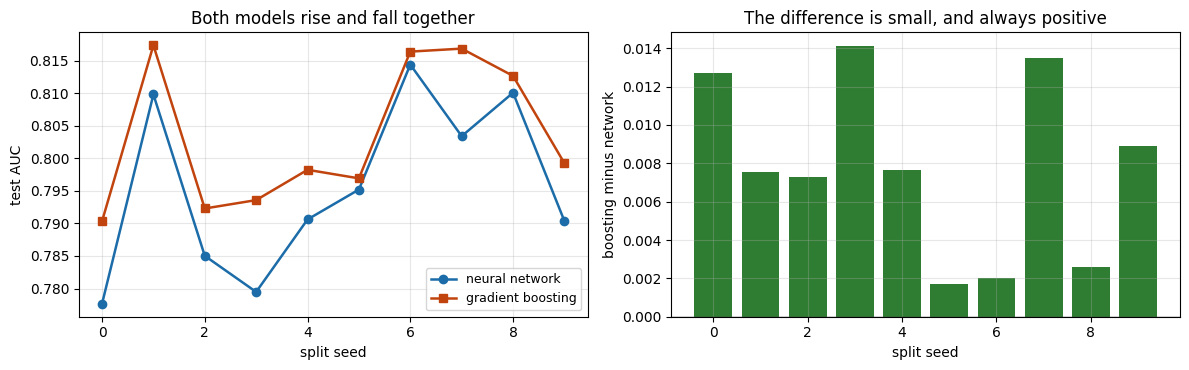

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

axes[0].plot(bakeoff.split, bakeoff.network, "o-", label="neural network", color="#1b6ca8", lw=1.8)
axes[0].plot(bakeoff.split, bakeoff.boosting, "s-", label="gradient boosting", color="#c1440e", lw=1.8)
axes[0].set_xlabel("split seed")
axes[0].set_ylabel("test AUC")
axes[0].set_title("Both models rise and fall together")
axes[0].legend(fontsize=9)

axes[1].bar(bakeoff.split, difference, color="#2e7d32")
axes[1].axhline(0, color="0.3", lw=1)
axes[1].set_xlabel("split seed")
axes[1].set_ylabel("boosting minus network")
axes[1].set_title("The difference is small, and always positive")

for axis in axes:
    axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

This is the heart of the note, so read the two panels together with the numbers above them.

**Summarised separately, the two models are indistinguishable.** The network averages 0.7956 with a standard deviation of 0.0132; boosting averages 0.8034 with 0.0111. The gap between the averages, 0.0078, is smaller than either spread. If you reported one sentence per model, you would have to say the comparison is inconclusive.

**Paired, the difference is +0.0078 with a standard deviation of 0.0047, and boosting wins all ten splits.** The left panel shows why: the two lines move up and down together, because a split that is hard for one model is hard for the other. Subtracting removes that shared movement, exactly as in the made-up example in Section 2.

So the honest statement is: **gradient boosting is better here, by a small and consistent margin of about 0.008 AUC.** Not "much better". Not "indistinguishable".

And there is a general lesson underneath it, which Day 3 could not have shown you with single runs: **a difference smaller than the noise floor can still be real**, as long as you measure it in a way that cancels the noise.

> **🖼 IMAGE 4.4.1 — why pairing changes the verdict**
>
> A two-panel statistical figure titled "Why pairing changes the verdict". Left panel: two wide, heavily overlapping bell curves labelled "neural network" and "gradient boosting", with the caption "each model across 10 splits: spread 0.013, gap 0.008 — inconclusive". Right panel: a single narrow bell curve sitting entirely to the right of a vertical zero line, labelled "difference, measured on the same splits", caption "spread 0.005, ahead on 10 of 10 — real". Inset in the right panel, ten pairs of dots connected by short arrows, every arrow pointing the same way. Clean figure style, two colours plus a grey zero line.

**Questions to sit with**

1. In your own words: why is the spread of the difference smaller than the spread of either model?
2. Suppose boosting had won 6 splits out of 10 with the same average difference. What would you conclude?
3. Would twenty more splits make the difference bigger? What would they improve?

<a id="s6"></a>
## 6. Does the tuning survive the noise?

The tuned settings won the search on validation. The rules said carry them to all ten splits, which we did. Now compare them with the untuned defaults, paired, exactly as before.

In [14]:
tuning_gain = bakeoff["boosting tuned"] - bakeoff["boosting"]

print("tuned minus default, across ten splits:")
print(f"  average            : {tuning_gain.mean():+.4f}")
print(f"  standard deviation : {tuning_gain.std(ddof=1):.4f}")
print(f"  tuned ahead on     : {int((tuning_gain > 0).sum())} of 10 splits")
print()
print("on split 42, the one the search was scored on:")
print(f"  validation AUC : tuned {grid.val_auc.max():.4f}  against default {gbdt_default['val_auc']:.4f}")
print(f"  test AUC       : tuned {grid.iloc[0].test_auc:.4f}  against default {gbdt_default['test']['auc']:.4f}")

tuned minus default, across ten splits:
  average            : +0.0012
  standard deviation : 0.0024
  tuned ahead on     : 5 of 10 splits

on split 42, the one the search was scored on:
  validation AUC : tuned 0.7994  against default 0.7944
  test AUC       : tuned 0.8109  against default 0.8160


The tuning moved the paired result by **+0.0012, with a standard deviation of 0.0024, winning five splits out of ten.** Five out of ten is a coin toss. The twelve-setting budget produced nothing.

The two lines underneath show how the illusion forms. On the split the search was scored on, the tuned settings beat the defaults on validation, 0.7994 against 0.7944 — exactly the kind of gain that gets written up. On the **test** rows of that same split they were **worse**, 0.8109 against 0.8160.

Picking the best of twelve noisy numbers partly picks luck, and luck does not transfer to new rows.

This is the same lesson Note 3.2 reached from the other direction, where eight different regularisation settings turned out to be indistinguishable once early stopping was in place. Searching a space of settings costs real time. Before spending it, check whether the space you are searching is wider than your noise. Here it was not: the whole search spanned 0.0068 and the split noise is 0.0130.

**Questions to sit with**

1. The tuned settings won on validation and lost on test, on the same split. What is the one-sentence explanation?
2. What would make a twelve-setting search worth running on this dataset?

<a id="s7"></a>
## 7. The cost column

Accuracy is one column of the decision. Here are the others, measured rather than assumed.

One caution about timing first, and it is the kind of thing that quietly makes comparisons unfair. Our network's timer covers 30 epochs **including** scoring the validation rows after each one, which is diagnostic work rather than training work. Gradient boosting's timer covers only its fit. To compare like with like, time the bare training loop as well.

In [15]:
split = split_42
pre = build_preprocessor(X).fit(X.iloc[split["train"]])
train_inputs = torch.tensor(pre.transform(X.iloc[split["train"]]).astype(np.float32))
train_targets = torch.tensor(y[split["train"]]).unsqueeze(1)

def bare_training_seconds(epochs=30):
    """The same 30 epochs, with no scoring in between."""
    torch.manual_seed(42)
    model = nn.Sequential(nn.Linear(train_inputs.shape[1], 64), nn.ReLU(),
                          nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0)
    loss_function = nn.BCEWithLogitsLoss()
    generator = torch.Generator().manual_seed(42)
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(train_inputs, train_targets),
        batch_size=256, shuffle=True, generator=generator)

    started = time.perf_counter()
    for _ in range(epochs):
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            loss_function(model(batch_x), batch_y).backward()
            optimizer.step()
    return time.perf_counter() - started

network_training_seconds = bare_training_seconds()
print(f"network, 30 epochs, training only        : {network_training_seconds:.2f} s")
print(f"network, as the run function reports it  : {nn_reference['seconds']:.2f} s (scoring included)")
print(f"gradient boosting, fit                   : {gbdt_default['seconds']:.2f} s")
print(f"ratio, training only                     : {network_training_seconds / gbdt_default['seconds']:.1f}x")

network, 30 epochs, training only        : 6.80 s
network, as the run function reports it  : 7.19 s (scoring included)
gradient boosting, fit                   : 0.49 s
ratio, training only                     : 13.8x


Next, how long each one takes to make predictions, and how big each one is to ship.

**Latency** means the time to produce predictions, measured here for 1,000 raw customer rows, with the preprocessing included, because in production you have to do that too. We take the median of five attempts, because single timings are noisy.

In [16]:
def latency_ms_per_1000_rows(predict, raw_rows, repeats=5):
    """Median milliseconds to score 1,000 raw rows, preprocessing included."""
    sample = raw_rows.iloc[:1000]
    times = []
    for _ in range(repeats):
        started = time.perf_counter()
        predict(sample)
        times.append(time.perf_counter() - started)
    return 1000 * float(np.median(times))

network_model = nn_reference["artifacts"]["model"]
network_preprocessor = nn_reference["artifacts"]["preprocessor"]

def network_predict(raw_rows):
    with torch.no_grad():
        return torch.sigmoid(network_model(
            torch.tensor(network_preprocessor.transform(raw_rows).astype(np.float32)))).numpy()

def boosting_predict(raw_rows):
    return gbdt_default["artifacts"]["model"].predict_proba(as_categorical(raw_rows))[:, 1]

test_rows_raw = X.iloc[split["test"]]
network_latency = latency_ms_per_1000_rows(network_predict, test_rows_raw)
boosting_latency = latency_ms_per_1000_rows(boosting_predict, test_rows_raw)

weights_buffer, preprocessor_buffer = io.BytesIO(), io.BytesIO()
torch.save(network_model.state_dict(), weights_buffer)
joblib.dump(network_preprocessor, preprocessor_buffer)
network_bytes = weights_buffer.getbuffer().nbytes + preprocessor_buffer.getbuffer().nbytes

print(f"network  : {network_latency:5.1f} ms per 1,000 rows | {network_bytes / 1024:5.0f} KB to ship")
print(f"boosting : {boosting_latency:5.1f} ms per 1,000 rows | "
      f"{gbdt_default['artifact_bytes'] / 1024:5.0f} KB to ship")

network  :   6.1 ms per 1,000 rows |    28 KB to ship
boosting :  13.4 ms per 1,000 rows |   344 KB to ship


In [17]:
cost_table = pd.DataFrame([
    {"": "test AUC over 10 splits",
     "neural network": f"{bakeoff.network.mean():.4f} ± {bakeoff.network.std(ddof=1):.4f}",
     "gradient boosting": f"{bakeoff.boosting.mean():.4f} ± {bakeoff.boosting.std(ddof=1):.4f}"},
    {"": "training time (seconds)",
     "neural network": f"{network_training_seconds:.2f}",
     "gradient boosting": f"{gbdt_default['seconds']:.2f}"},
    {"": "prediction, ms per 1,000 rows",
     "neural network": f"{network_latency:.1f}", "gradient boosting": f"{boosting_latency:.1f}"},
    {"": "size to ship (KB)",
     "neural network": f"{network_bytes / 1024:.0f}",
     "gradient boosting": f"{gbdt_default['artifact_bytes'] / 1024:.0f}"},
    {"": "preparation needed",
     "neural network": "scale + one-hot, 15 columns -> 50",
     "gradient boosting": "mark categories, 15 columns"},
    {"": "files to ship",
     "neural network": "weights + fitted preprocessor", "gradient boosting": "one model file"},
    {"": "settings that matter",
     "neural network": "learning rate, epochs, width, batch size, regularisation",
     "gradient boosting": "learning rate, leaves, number of trees"},
    {"": "does a GPU help?",
     "neural network": "yes, at larger scale", "gradient boosting": "no"},
])
print(cost_table.to_string(index=False))

                                                                        neural network                      gradient boosting
      test AUC over 10 splits                                          0.7956 ± 0.0132                        0.8034 ± 0.0111
      training time (seconds)                                                     6.80                                   0.49
prediction, ms per 1,000 rows                                                      6.1                                   13.4
            size to ship (KB)                                                       28                                    344
           preparation needed                        scale + one-hot, 15 columns -> 50            mark categories, 15 columns
                files to ship                            weights + fitted preprocessor                         one model file
         settings that matter learning rate, epochs, width, batch size, regularisation learning rate, leaves, number o

Read that as a set of trades rather than a scoreboard.

**Training.** Boosting fits in 0.49 seconds against 6.80 for the network's 30 epochs — about **14 times faster** on the same machine — with no epoch count to choose and no learning rate to get wrong.

**Prediction.** The network is the faster one here, 6.1 ms per 1,000 rows against 13.4, because scoring it is a few small matrix multiplications while boosting has to walk dozens of trees. Its files are also far smaller, 28 KB against 344 KB.

**Everything else.** The network needs a fitted preprocessor that has to be saved, versioned and kept in step with the weights — which is exactly what Note 4.2's bundle existed to manage. Boosting ships one file and takes the raw columns.

At this volume of requests none of the prediction numbers is a constraint, which is why the accuracy and training columns carry the decision. At a hundred thousand requests a second, or on a device with a hard size limit, the same table would point the other way.

**Questions to sit with**

1. The run function's timer included scoring. Name another way a timing comparison can quietly become unfair.
2. At what dataset size would you expect the training-time ratio to start favouring the network?

<a id="s8"></a>
## 8. The robustness column

Everything so far used the stratified split, which answers "how well on a random customer from 2008 to 2010?". Note 4.1 showed that the deployment question is different, and that the chronological split answers it: train on the earliest 80% of the file, test on the last 10%, where 47% of customers say yes.

Run both models there.

In [18]:
chronological = {
    "network": run_neural_network({"name": "bake_nn_chrono", "split": "chronological"}, quiet=True),
    "boosting": run_gradient_boosting({"name": "bake_gbdt_chrono", "split": "chronological"}, quiet=True),
    "boosting tuned": run_gradient_boosting({"name": "bake_tuned_chrono", "split": "chronological",
                                             **TUNED}, quiet=True),
}

comparison = pd.DataFrame([
    {"model": name,
     "stratified test AUC": bakeoff[name].mean() if name in bakeoff else np.nan,
     "chronological test AUC": result["test"]["auc"],
     "average prediction": result["test"]["average_prediction"],
     "share who actually said yes": result["test"]["share_who_said_yes"]}
    for name, result in chronological.items()])
print(comparison.round(4).to_string(index=False))
print()
print(f"network's best epoch under the chronological split: "
      f"{chronological['network']['best_epoch']} (it was {nn_reference['best_epoch']} on the stratified one)")

         model  stratified test AUC  chronological test AUC  average prediction  share who actually said yes
       network               0.7956                  0.6141              0.1284                       0.4709
      boosting               0.8034                  0.5841              0.1863                       0.4709
boosting tuned               0.8046                  0.5714              0.1771                       0.4709

network's best epoch under the chronological split: 2 (it was 18 on the stratified one)


Both models fall a long way, and **the ranking reverses**. The network, which lost on every stratified split, is now the better of the two.

Before making anything of that, notice the problem: this is **one** test set, not ten. Time only runs in one direction, so there is no second chronological split to compare against.

The tool for that situation is the **bootstrap**. The idea is simple: treat your test set as a stand-in for the population, and draw a new test set from it *with replacement* — meaning the same row can be drawn twice, and some rows not at all. Score both models on that resample. Do it a thousand times, and the spread of the differences tells you how much your single result depends on which particular rows you happened to have.

In [19]:
network_probabilities = chronological["network"]["artifacts"]["test_probabilities"]
boosting_probabilities = chronological["boosting"]["artifacts"]["test_probabilities"]
chronological_labels = y[chronological["network"]["artifacts"]["split"]["test"]]

point_estimate = (roc_auc_score(chronological_labels, network_probabilities)
                  - roc_auc_score(chronological_labels, boosting_probabilities))

generator = np.random.default_rng(0)
n_rows = len(chronological_labels)
differences = []
for _ in range(1000):
    picked = generator.integers(0, n_rows, n_rows)          # draw n rows, with replacement
    if chronological_labels[picked].sum() in (0, len(picked)):
        continue                                            # skip a resample with only one class
    differences.append(roc_auc_score(chronological_labels[picked], network_probabilities[picked])
                       - roc_auc_score(chronological_labels[picked], boosting_probabilities[picked]))

differences = np.array(differences)
low, high = np.percentile(differences, [2.5, 97.5])
print(f"chronological split, network minus boosting")
print(f"  measured on the real test rows : {point_estimate:+.4f}")
print(f"  95% of resamples fall between  : {low:+.4f} and {high:+.4f}")
print(f"  resamples where the network is ahead: {(differences > 0).mean():.1%}")

chronological split, network minus boosting
  measured on the real test rows : +0.0300
  95% of resamples fall between  : +0.0172 and +0.0437
  resamples where the network is ahead: 100.0%


The network is ahead by **0.0300**, and the interval from **+0.0172 to +0.0437** does not include zero, with the network ahead in **100%** of the resamples. So the reversal is not an accident of which rows landed in that one test set.

Notice how much larger this gap is than the 0.0078 that separated the models on the stratified splits. The shift changed the ranking by roughly four times the margin the original comparison was arguing about.

The network's best epoch also moved, from 18 down to 2. Its validation rows now come from a later, different period, so the run reaches its best general performance almost immediately and then spends 28 more epochs fitting itself more tightly to a training period that no longer describes the world.

Why would the more flexible model suffer more? Because flexibility is fitted to the training distribution. Gradient boosting carves the old population into many fine regions, and when the population moves, a lot of those regions no longer describe anybody. The smaller, smoother model has less to be wrong about. That is a pattern worth carrying forward, not a fact about these two libraries.

And be careful what this does **not** say. It does not say the network is fit to deploy. Both models lose most of their skill, and both are badly miscalibrated on the later period, predicting far below the true rate of 47%. The honest conclusion is that **the shift is the dominant problem**, and it is bigger than the choice of model.

> **🖼 IMAGE 4.4.2 — the ranking reverses**
>
> A slope chart titled "The ranking reverses when the question changes". Two vertical axes side by side, both labelled test AUC from 0.55 to 0.85. Left axis, "stratified split — a random customer": "gradient boosting" plotted at 0.8034 above "neural network" at 0.7956. Right axis, "chronological split — next month's campaign": the same two models at 0.5841 and 0.6141, with the network now on top. Two labelled lines connect each model across the two axes and visibly cross. A grey band across the lower part of the chart labelled "both models have lost most of their skill here". Caption: "The shift is a bigger problem than the choice of model."

**Questions to sit with**

1. Why bootstrap the test rows here instead of running ten chronological splits?
2. The interval covers the wobble from which rows you tested on. Name a source of uncertainty it does **not** cover.
3. Both models are badly calibrated on the later period. What would you do about that before shipping either?

<a id="s9"></a>
## 9. Where the two models disagree

Two models with nearly the same AUC are not necessarily making the same predictions. On the stratified split, compare them customer by customer.

**Spearman correlation** measures whether two sets of scores put things in the same *order*, ignoring the actual values. 1.0 means identical order; 0 means no relationship.

In [20]:
from scipy.stats import spearmanr

network_test = nn_reference["artifacts"]["test_probabilities"]
boosting_test = gbdt_default["artifacts"]["test_probabilities"]
labels_test = y[split["test"]]

print(f"how similarly they rank customers (Spearman): {spearmanr(network_test, boosting_test)[0]:.4f}")
print(f"neural network AUC     : {roc_auc_score(labels_test, network_test):.4f}")
print(f"gradient boosting AUC  : {roc_auc_score(labels_test, boosting_test):.4f}")
print(f"the two averaged       : {roc_auc_score(labels_test, (network_test + boosting_test) / 2):.4f}")

how similarly they rank customers (Spearman): 0.8658
neural network AUC     : 0.8016
gradient boosting AUC  : 0.8160
the two averaged       : 0.8163


In [21]:
slices = {
    "contacted in an earlier campaign": (test_rows_raw.pdays > -1).to_numpy(),
    "never contacted before": (test_rows_raw.pdays == -1).to_numpy(),
    "contact type known": (test_rows_raw.contact != "unknown").to_numpy(),
    "contact type unknown": (test_rows_raw.contact == "unknown").to_numpy(),
}

slice_rows = []
for name, mask in slices.items():
    slice_rows.append({"slice": name, "rows": int(mask.sum()),
                       "share who said yes": labels_test[mask].mean(),
                       "network AUC": roc_auc_score(labels_test[mask], network_test[mask]),
                       "boosting AUC": roc_auc_score(labels_test[mask], boosting_test[mask])})

slice_table = pd.DataFrame(slice_rows)
slice_table["boosting minus network"] = slice_table["boosting AUC"] - slice_table["network AUC"]
print(slice_table.round(4).to_string(index=False))

                           slice  rows  share who said yes  network AUC  boosting AUC  boosting minus network
contacted in an earlier campaign   843              0.2444       0.8547        0.8640                  0.0093
          never contacted before  3679              0.0878       0.7478        0.7675                  0.0198
              contact type known  3187              0.1490       0.7984        0.8156                  0.0172
            contact type unknown  1335              0.0404       0.6246        0.6210                 -0.0036


The two models rank customers similarly but not identically: a Spearman correlation of 0.8658. Averaging their predictions gives 0.8163 against boosting's 0.8160, so combining them bought nothing worth shipping a second model for.

The slices are more useful. Boosting is ahead on three of the four, and its biggest advantage is on customers **never contacted before** (+0.0198), which is also the largest and hardest slice — its ability to carve up the raw categorical columns evidently helps there. On customers whose **contact type is unknown**, the two are level (−0.0036), and that slice is where both models are weakest in absolute terms: 0.6246 for the network and 0.6210 for boosting, against 0.75 to 0.86 everywhere else.

That slice was flagged in Note 4.1 as a suspicious 28.8% of rows with a low success rate, and Note 4.1 Section 8 found it shrinking sharply over time. Neither model solves it, and no amount of model choice will. That is a data question, and it is the kind of thing Day 9's error analysis is built to chase.

<a id="s10"></a>
## 10. The decision memo

The blueprint asks for a decision rule, not a winner. Here is the memo, written from the measurements above, and then a short record for each side in the Note 4.2 format.

In [22]:
memo = f"""# Decision memo: model choice for Bank Marketing subscription prediction

## Recommendation
Ship **gradient boosting** (HistGradientBoostingClassifier, default settings) for this problem
at this size, and treat the distribution shift as more urgent than the choice of model.

## Evidence
- Accuracy, 10 paired stratified splits: boosting {bakeoff.boosting.mean():.4f} against
  network {bakeoff.network.mean():.4f}. Paired difference {difference.mean():+.4f}
  (standard deviation {difference.std(ddof=1):.4f}), boosting ahead on
  {int((difference > 0).sum())} of 10 splits. Small, consistent, real.
- Tuning: a twelve-setting search changed the paired result by {tuning_gain.mean():+.4f}
  (standard deviation {tuning_gain.std(ddof=1):.4f}), ahead on {int((tuning_gain > 0).sum())} of 10.
  Not worth the budget.
- Cost: trains {network_training_seconds / gbdt_default['seconds']:.0f}x faster, with no scaling or
  one-hot pipeline to fit, maintain and ship. Predictions are slower per 1,000 rows
  ({boosting_latency:.1f} ms against {network_latency:.1f} ms) and the file is larger
  ({gbdt_default['artifact_bytes'] / 1024:.0f} KB against {network_bytes / 1024:.0f} KB); at this
  request volume neither is a constraint.
- Robustness: under a chronological split both models collapse
  (boosting {chronological['boosting']['test']['auc']:.4f},
  network {chronological['network']['test']['auc']:.4f}) and the ranking reverses,
  with a bootstrap interval that excludes zero. Neither is calibrated for the later period.

## What would change this recommendation
- Much more data, or raw text, image, audio or sequence inputs: revisit. That is where
  neural networks win, and it is what Days 5 to 9 are about.
- A need to fine-tune a pretrained model, or to share an encoder with another task:
  gradient boosting cannot do either.
- Prediction budgets in the low milliseconds per 1,000 rows, or a hard file-size limit.

## Conditions on deployment
- Retrain on a schedule. The success rate moved about tenfold across this file.
- Watch the input distribution (Note 4.1's adversarial check) and recalibrate on recent data.
- Choose the decision threshold from calling capacity, not from 0.5 (Note 4.1 Section 10).

## Limitations
- One dataset, one size, tabular only. This is not a general claim about model families.
- The network's settings came from two days of tuning in Notes 2.3 to 3.4; boosting got
  twelve settings. The imbalance favours the network, and it still lost.
- The chronological result is a single split; its bootstrap interval is in results/.
"""

os.makedirs("results", exist_ok=True)
with open("results/decision_memo.md", "w") as f:
    f.write(memo)
print(memo)

# Decision memo: model choice for Bank Marketing subscription prediction

## Recommendation
Ship **gradient boosting** (HistGradientBoostingClassifier, default settings) for this problem
at this size, and treat the distribution shift as more urgent than the choice of model.

## Evidence
- Accuracy, 10 paired stratified splits: boosting 0.8034 against
  network 0.7956. Paired difference +0.0078
  (standard deviation 0.0047), boosting ahead on
  10 of 10 splits. Small, consistent, real.
- Tuning: a twelve-setting search changed the paired result by +0.0012
  (standard deviation 0.0024), ahead on 5 of 10.
  Not worth the budget.
- Cost: trains 14x faster, with no scaling or
  one-hot pipeline to fit, maintain and ship. Predictions are slower per 1,000 rows
  (13.4 ms against 6.1 ms) and the file is larger
  (344 KB against 28 KB); at this
  request volume neither is a constraint.
- Robustness: under a chronological split both models collapse
  (boosting 0.5841,
  network 0.6141) and the r

And the records, in the five-question format from Note 4.2. The function is repeated here so this notebook stands alone.

In [23]:
def experiment_record(result, why, learned, next_change, results_dir="results"):
    """Write results/<name>.md: the five questions every experiment should answer."""
    if not why or not learned:
        raise ValueError("a record needs both a reason and a lesson")
    test = result["test"]
    text = f"""### Experiment: {result['name']}

model: {result['model']} · settings: `{result['settings']}`

**1. What did I try?** {result['model']} on Bank Marketing, stratified split, seed
{result['settings']['split_seed']}.

**2. Why?** {why}

**3. What happened?** validation AUC {result['val_auc']:.4f}; test AUC {test['auc']:.4f},
test PR-AUC {test['pr_auc']:.4f} (share who said yes {test['share_who_said_yes']:.3f});
{result['seconds']:.2f} seconds to fit.

**4. What did I learn?** {learned}

**5. What would I change next?** {next_change}

Full numbers: `{results_dir}/{result['name']}.json`
"""
    path = os.path.join(results_dir, f"{result['name']}.md")
    with open(path, "w") as f:
        f.write(text)
    return path

experiment_record(
    nn_reference,
    why=("The Day 3 network, frozen, should be competitive with gradient boosting on this "
         "tabular dataset. The blueprint warns that it may not win."),
    learned=(f"It lost on all ten paired splits, by {abs(difference.mean()):.4f} AUC on average. "
             f"That margin is smaller than the 0.013 split noise but consistent in direction. "
             f"It was the more robust of the two under the chronological split."),
    next_change=("Repeat the comparison on a dataset with raw text or sequence inputs, where the "
                 "advantage of learned representations should show."))

path = experiment_record(
    gbdt_default,
    why="Default gradient boosting should be a strong baseline on tabular data with no tuning.",
    learned=(f"Confirmed: defaults reached {gbdt_default['test']['auc']:.4f} test AUC in "
             f"{gbdt_default['seconds']:.2f} seconds with no preprocessing, and a twelve-setting "
             f"search added {tuning_gain.mean():+.4f} across splits, which is noise."),
    next_change="Try LightGBM and XGBoost on the same splits for a like-for-like check.")
print(open(path).read())

### Experiment: bakeoff_gbdt_42

model: gradient boosting · settings: `{'name': 'bakeoff_gbdt_42', 'split': 'stratified', 'split_seed': 42, 'seed': 42, 'learning_rate': 0.1, 'max_leaf_nodes': 31, 'l2_regularization': 0.0, 'max_iter': 100, 'early_stopping': 'auto'}`

**1. What did I try?** gradient boosting on Bank Marketing, stratified split, seed
42.

**2. Why?** Default gradient boosting should be a strong baseline on tabular data with no tuning.

**3. What happened?** validation AUC 0.7944; test AUC 0.8160,
test PR-AUC 0.4944 (share who said yes 0.117);
0.49 seconds to fit.

**4. What did I learn?** Confirmed: defaults reached 0.8160 test AUC in 0.49 seconds with no preprocessing, and a twelve-setting search added +0.0012 across splits, which is noise.

**5. What would I change next?** Try LightGBM and XGBoost on the same splits for a like-for-like check.

Full numbers: `results/bakeoff_gbdt_42.json`



In [24]:
records = sorted(f for f in os.listdir("results") if f.endswith(".md"))
results = sorted(f for f in os.listdir("results") if f.endswith(".json"))
print(f"{len(results)} result files and {len(records)} written records in results/")
print("records:", records)

50 result files and 5 written records in results/
records: ['bakeoff_gbdt_42.md', 'bakeoff_nn_42.md', 'data_card_bank_marketing.md', 'decision_memo.md', 'weights_only.md']


<a id="s11"></a>
## 11. Your turn

Three extensions, in increasing order of effort. Each one follows the same rules: declare the budget first, use the same splits, report the paired difference against the noise, and write the record.

1. **A third model.** Add logistic regression to the ten-split comparison. Note 3.1 reported 0.7717 for it on the Day 2 split. Does it survive a paired comparison against the other two, and what does its cost column look like?
2. **The imbalance question.** Run the network with `pos_weight` set to 7.5, roughly the ratio of no answers to yes answers, across the same ten splits. Note 4.1 Section 10 predicts the ranking will not change. Check it, and check the calibration too.
3. **Combining them.** Section 9 averaged the two models on one split. Does the average beat the better model across all ten, paired? If it does, is the gain worth shipping two models and maintaining both?

In [25]:
# Scratch space for your extensions.
# for seed in range(10):
#     ...

print("ready")

ready


### What to take away

**Write the rules before the first result.** The measure, the splits, the tuning budget, the decision rule, and what would change your mind. A comparison without them measures effort, not models.

**Compare on identical rows and look at the paired difference.** A gap smaller than the noise floor can still be real, and a gap larger than it can still be luck if the two models saw different rows.

**Check tuning gains against the noise.** Twelve settings spanning less than the split noise cannot produce a finding, however carefully you rank them.

**Accuracy is one column.** Training time, prediction time, file size, preparation needed, the number of things that can break in production, and behaviour under shift all belong in the decision.

**Test the deployment condition, not just the convenient one.** The ranking reversed under the chronological split, and both models lost most of their skill. That finding matters more than the 0.008 that separated them.

**On tabular data of this size, gradient boosting is the baseline to beat.** Deep learning's advantage is learning representations from raw inputs — text, images, audio, sequences — which is exactly where Days 5 to 9 go.

### Where Day 4 leaves you

Across the four notes you have built the engineering layer the rest of the course runs on:

```text
4.1  data you can trust      audit, split rules and a contract, leakage measured three ways
4.2  experiments you can     seeds, settings, records, checkpoints that resume,
     reproduce               and the size of the noise
4.3  memory and precision    what a run costs before you start it, and the OOM playbook
4.4  the bake-off            a controlled comparison with error bars, cost, robustness,
                             and a written decision
```

That is the blueprint's Day 4 competency: **conduct and communicate a defensible Deep Learning experiment.**

### Transition to Day 5

Day 4's conclusion also points straight at Day 5. Gradient boosting won on 15 tabular columns that people had already engineered into something useful. It has no answer at all when the input is a sentence, a photograph or a recording, because there is nothing to split on until somebody builds features by hand.

That gap is exactly what representation learning fills. Day 5 asks how a network turns raw input into a representation that makes a task easy, what an embedding is, how similarity works in that space, and how CLIP puts a picture and a sentence into the same space. From there, Day 6 opens the architecture that learns the best representations we currently have: the Transformer.